# Score matching

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import tqdm
from sklearn.datasets import make_swiss_roll

## Datos de entrenamiento

In [ ]:
def get_batch(batch_size=100, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

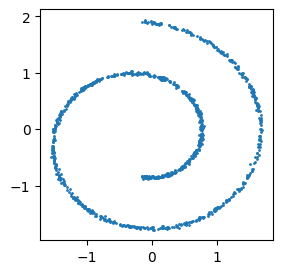

In [ ]:
samples = get_batch(batch_size=1000)
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Red neuronal

Red compartida $s_\theta:\mathbb{R}^D\to\mathbb{R}^D$ utilizada por SM y DSM para aproximar el score $\nabla_x\log p(x)$.

In [ ]:
class ScoreNetwork(nn.Module):

    def __init__(self, data_dim=2):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(data_dim, 64), nn.LogSigmoid(),
            nn.Linear(64, 64), nn.LogSigmoid(),
            nn.Linear(64, 64), nn.LogSigmoid(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x):
        return self.mlp(x)

## Clase base `ScoreMatching`

`SM` y `DSM` comparten exactamente el mismo entrenamiento y la misma generación (Langevin sampling), solo difieren en la función de pérdida.

In [ ]:
class ScoreMatching:

    @staticmethod
    def loss_fn(net, x):
        raise NotImplementedError

    @classmethod
    def train_model(cls, net, optimizer, n_iters):
        for _ in tqdm.trange(n_iters):
            loss = cls.loss_fn(net, get_batch())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    @staticmethod
    def generate_samples(net, n_samples, step_size=0.001, n_steps=1000):
        with torch.no_grad():
            x = torch.randn((n_samples, 2))
            for _ in range(n_steps):
                z = torch.randn_like(x)
                x = x + step_size * net(x) + (2 * step_size) ** 0.5 * z
            return x

## Score matching (SM)

Se entrena minimizando la divergencia de Fisher reescrita como
$$\mathbb{E}_{p_\text{data}(x)}\left[\tfrac{1}{2}\|s_\theta(x)\|^2 + \operatorname{Div}_x s_\theta(x)\right]$$
La generación de muestras se realiza mediante Langevin sampling usando directamente $s_\theta(x)$.

In [ ]:
class SM(ScoreMatching):

    @staticmethod
    def loss_fn(net, x):
        score = net(x)
        score_norm = 1/2 * torch.linalg.norm(score, dim=-1) ** 2
        jacobian = torch.vmap(torch.func.jacrev(net))(x)
        divergence = torch.vmap(torch.trace)(jacobian)
        return (score_norm + divergence).mean()

100%|██████████| 30000/30000 [00:47<00:00, 632.26it/s]


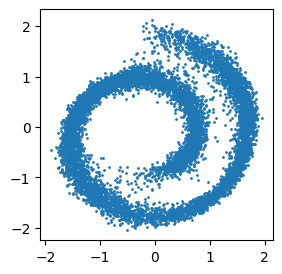

In [ ]:
sm_net = ScoreNetwork(data_dim=2)
sm_optimizer = optim.Adam(sm_net.parameters(), lr=3e-4)
SM.train_model(sm_net, sm_optimizer, n_iters=30000)

sm_samples = SM.generate_samples(sm_net, n_samples=10000)
plt.figure(figsize=(3, 3))
plt.scatter(sm_samples[:, 0], sm_samples[:, 1], s=1)
plt.show()

## Denoising score matching (DSM)

Con $q_\sigma(\tilde x|x)=\mathcal{N}(x,\sigma^2 I)$ y score condicional $\nabla_{\tilde x}\log q_\sigma(\tilde x|x)=-\tfrac{\tilde x - x}{\sigma^2}$, se minimiza
$$\mathbb{E}_{p_\text{data}(x),\,\epsilon\sim\mathcal{N}(0,I)}\left[\tfrac{1}{2}\left\|s_\theta(x+\sigma\epsilon)+\tfrac{\epsilon}{\sigma}\right\|^2\right]$$

In [ ]:
class DSM(ScoreMatching):

    sigma = 0.1

    @classmethod
    def loss_fn(cls, net, x):
        epsilon = torch.randn_like(x)
        x_tilde = x + cls.sigma * epsilon
        score = net(x_tilde)
        return 1/2 * (torch.linalg.norm(score + epsilon / cls.sigma, dim=-1) ** 2).mean()

100%|██████████| 30000/30000 [00:17<00:00, 1713.20it/s]


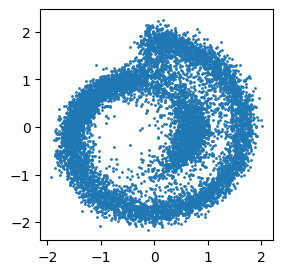

In [ ]:
dsm_net = ScoreNetwork(data_dim=2)
dsm_optimizer = optim.Adam(dsm_net.parameters(), lr=3e-4)
DSM.train_model(dsm_net, dsm_optimizer, n_iters=30000)

dsm_samples = DSM.generate_samples(dsm_net, n_samples=10000)
plt.figure(figsize=(3, 3))
plt.scatter(dsm_samples[:, 0], dsm_samples[:, 1], s=1)
plt.show()

## DSM con varios niveles de ruido

Se usa una secuencia creciente de ruidos $(\sigma_k)_{k=1}^K$ y una única red $s_\theta:\mathbb{R}^D\times\mathbb{R}_{++}\to\mathbb{R}^D$ condicionada en $\sigma$, entrenada para minimizar la pérdida combinada

\begin{align*}
\mathcal{L}_\text{DSM}(\theta) = \mathbb{E}_{k\sim\text{Uniforme}\{1,\ldots,K\},\,x\sim p_\text{data},\,\epsilon\sim\mathcal{N}(0,I_D)}\left[\tfrac{\sigma_k^2}{2}\left\|s_\theta(x+\sigma_k\epsilon,\sigma_k)+\tfrac{\epsilon}{\sigma_k}\right\|^2\right]
\end{align*}

Por otro lado, la red se reparametriza como $s_\theta(x,\sigma)=\text{NN}_\theta(x,\sigma)/\sigma$, de modo que el peso $\sigma_k^2$ convierte la pérdida en $\tfrac{1}{2}\|\text{NN}_\theta(x+\sigma_k\epsilon,\sigma_k)+\epsilon\|^2$: la red predice una cantidad $O(1)$ (esencialmente $-\epsilon$) en vez del score real (cercano a $1/\sigma$), lo que estabiliza el entrenamiento y la generación, la cual se realiza mediante annealed Langevin sampling.


In [ ]:
class ConditionalScoreNetwork(nn.Module):

    def __init__(self, data_dim=2):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(data_dim + 1, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, data_dim)
        )

    def forward(self, x, sigma):
        h = torch.cat([x, torch.log(sigma)], dim=-1)
        return self.mlp(h) / sigma

class MultiNoiseDSM:

    @staticmethod
    def loss_fn(net, x, sigmas):
        idx = torch.randint(len(sigmas), (x.shape[0],))
        sigma = sigmas[idx].unsqueeze(-1)  # (batch, 1)

        epsilon = torch.randn_like(x)
        x_tilde = x + sigma * epsilon
        score = net(x_tilde, sigma)
        inner = torch.linalg.norm(score + epsilon / sigma, dim=-1) ** 2
        return 1/2 * (sigma.squeeze(-1) ** 2 * inner).mean()

    @staticmethod
    def train_model(net, optimizer, sigmas, n_iters):
        for _ in tqdm.trange(n_iters):
            loss = MultiNoiseDSM.loss_fn(net, get_batch(), sigmas)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            optimizer.step()

    @staticmethod
    def generate_samples(net, sigmas, n_samples, lr=1e-4, n_steps=200):
        with torch.no_grad():
            x = torch.zeros((n_samples, 2))
            for sigma in reversed(sigmas):
                step_size = lr * (sigma / sigmas[0]) ** 2
                sigma_batch = sigma * torch.ones(n_samples, 1)
                for _ in range(n_steps):
                    z = torch.randn_like(x)
                    x = x + step_size * net(x, sigma_batch) + (2 * step_size) ** 0.5 * z
            return x

100%|██████████| 30000/30000 [00:25<00:00, 1175.14it/s]


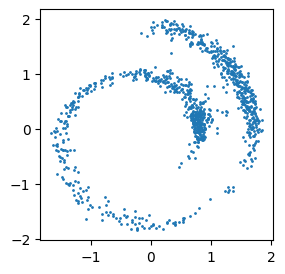

In [ ]:
sigmas = torch.logspace(-2, 0, steps=10)

mn_net = ConditionalScoreNetwork(data_dim=2)
mn_optimizer = optim.Adam(mn_net.parameters(), lr=3e-4)
MultiNoiseDSM.train_model(mn_net, mn_optimizer, sigmas, n_iters=30000)

mn_samples = MultiNoiseDSM.generate_samples(mn_net, sigmas, n_samples=1000)
plt.figure(figsize=(3, 3))
plt.scatter(mn_samples[:, 0], mn_samples[:, 1], s=1)
plt.show()